---

## 🧠 Step 1: Load & Preview the Data

* using best practices for HEDIS-style hospital visit analysis in Jupyter within VS Code.

  * build a clean, reproducible pipeline with modular logic and recruiter-friendly documentation.

### ✅ Code
```python
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file
df = pd.read_csv('data/hospital_visits.csv')

# Preview the first few rows
df.head()
```

### 📋 What the Output Shows
- **Rows**: Each row represents a hospital visit by a patient.
- **Columns**:
  - `Row_ID`: Unique identifier for each visit.
  - `Date of Admit` & `Date of Discharge`: Admission and discharge dates.
  - `Doctor`, `Hospital Branch`, `Department Type`, `Department`: Operational metadata.
  - `Patient ID`, `Patient Name`, `Patient Risk Profile`: Patient-level identifiers and risk stratification.
  - `Revenue`, `Minutes to Service`, `Number of Patient Visits`: Key metrics for utilization and performance.

### 🧠 Why This Matters
- This structure supports HEDIS-style analysis by enabling:
  - **Eligibility logic** (e.g., risk profile, department)
  - **Utilization metrics** (e.g., length of stay, service time)
  - **Performance insights** (e.g., revenue vs. visits)

---

## 🔜 Next Step: Step 2 – Clean & Normalize Column Names

   * standardize column names to `snake_case`, convert date columns to `datetime`, and prepare for feature engineering.

In [7]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
os.getcwd()
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load your CSV file
df = pd.read_csv('../data/hospital_visits.csv')

# Preview the data
df.head()


,Row_ID,Date of Admit,Date of Discharge,Doctor,Hospital Branch,Department Type,Department,Patient ID,Patient Name,Patient Risk Profile,Revenue,Minutes to Service,Number of Patient Visits
0,6411,2/7/2019,2/12/2019,Leonard McCoy,East,General,General Surgery,2180,Bernard Strauss,Low,13420,23,1
1,6412,7/22/2019,NaN,Joseph Lister,Central,Labs,Microbiology,1389,Joel Buckley,Low,1280,20,1
2,6415,2/19/2018,NaN,Virginia Apgar,Central,Labs,Haematology,3330,Kara Foster,High,5300,11,1
3,6416,10/6/2019,10/7/2019,Anastasia Golovina,East,Specialty,Gastroenterology,2680,Esther Whitaker,Low,4015,23,1
4,8046,12/31/2019,1/3/2020,Anastasia Golovina,East,Specialty,Gastroenterology,2654,Bob Jiang,High,2035,9,1


Absolutely, Salome. Here's your **Step 2: Clean & Normalize Column Names** written in Markdown with code, interpretation, and validation—ready to drop into your notebook:

---

## 🛠️ Step 2: Clean & Normalize Column Names

### 🔄 1. Standardize Column Names to `snake_case`
```python
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
```
- Removes leading/trailing spaces
- Converts all column names to lowercase
- Replaces spaces with underscores for consistency

✅ **Why it matters**: Improves readability, avoids key errors, and supports reproducible code.

---

### 📅 2. Convert Date Columns to `datetime`
```python
df['date_of_admit'] = pd.to_datetime(df['date_of_admit'], errors='coerce')
df['date_of_discharge'] = pd.to_datetime(df['date_of_discharge'], errors='coerce')
```
- Converts string-based dates into proper `datetime` format
- `errors='coerce'` ensures invalid entries become `NaT` (missing), which can be handled safely

✅ **Why it matters**: Enables time-based calculations like length of stay, trends, and seasonal analysis.

---

### 🔍 3. Validate Conversion
```python
df[['date_of_admit', 'date_of_discharge']].dtypes
```
Expected output:
```
date_of_admit        datetime64[ns]
date_of_discharge    datetime64[ns]
```

---

### 🧪 4. Check for Missing Dates
```python
df[['date_of_admit', 'date_of_discharge']].isnull().sum()
```
- Identifies rows with missing admission or discharge dates
- Helps flag ongoing admissions or incomplete records

---

### ✅ Summary
| Task                        | Outcome |
|----------------------------|---------|
| Column normalization       | All columns in `snake_case` |
| Date conversion            | `datetime64` format for admit/discharge |
| Missing value awareness    | Ready for feature engineering |

---

Next **Step 3: Feature Engineering – Length of Stay & Admission Flags**. calculating stay duration and identifying ongoing admissions.

In [9]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')



In [10]:
df['date_of_admit'] = pd.to_datetime(df['date_of_admit'], errors='coerce')
df['date_of_discharge'] = pd.to_datetime(df['date_of_discharge'], errors='coerce')


In [11]:
df[['date_of_admit', 'date_of_discharge']].dtypes


date_of_admit        datetime64[ns]
date_of_discharge    datetime64[ns]
dtype: object

In [12]:
df[['date_of_admit', 'date_of_discharge']].isnull().sum()
# Date of Discharge has ~18% missing values.

date_of_admit           0
date_of_discharge    1139
dtype: int64

In [13]:
df.info()
df.describe(include='all')
df.columns
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6334 entries, 0 to 6333
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   row_id                    6334 non-null   int64         
 1   date_of_admit             6334 non-null   datetime64[ns]
 2   date_of_discharge         5195 non-null   datetime64[ns]
 3   doctor                    6334 non-null   object        
 4   hospital_branch           6334 non-null   object        
 5   department_type           6334 non-null   object        
 6   department                6334 non-null   object        
 7   patient_id                6334 non-null   int64         
 8   patient_name              6334 non-null   object        
 9   patient_risk_profile      6334 non-null   object        
 10  revenue                   6334 non-null   int64         
 11  minutes_to_service        6334 non-null   int64         
 12  number_of_patient_vi

row_id                         0
date_of_admit                  0
date_of_discharge           1139
doctor                         0
hospital_branch                0
department_type                0
department                     0
patient_id                     0
patient_name                   0
patient_risk_profile           0
revenue                        0
minutes_to_service             0
number_of_patient_visits       0
dtype: int64

Excellent, Salome. Your data is now clean, well-typed, and ready for feature engineering. Let’s proceed step-by-step with **Step 3: Feature Engineering – Length of Stay & Admission Flags**.

---

## 🧮 Step 3: Feature Engineering – Length of Stay & Admission Flags

### 🔢 1. Calculate `length_of_stay`
```python
df['length_of_stay'] = (df['date_of_discharge'] - df['date_of_admit']).dt.days
# Calculates hospital stay duration in days.
# Enables analysis of utilization, cost, and risk stratification.
df['length_of_stay'].describe()
```

- This computes the number of days between admission and discharge.
- If `date_of_discharge` is missing (`NaT`), the result will be `NaN`.

✅ **Why it matters**: Length of stay is a core utilization metric in HEDIS and hospital performance analysis.

---

### 🏷️ 2. Flag Ongoing Admissions
```python
df['ongoing_admission'] = df['date_of_discharge'].isnull()
df['ongoing_admission'].value_counts()
# Flags records with missing discharge dates as ongoing admissions.
# Important for accurate length of stay and cost analyses.
```

- Creates a boolean column: `True` if the patient is still admitted (no discharge date), `False` otherwise.

✅ **Why it matters**: Helps isolate incomplete records or patients still under care.

---

### 🔍 3. Validate the New Features
```python
df[['date_of_admit', 'date_of_discharge', 'length_of_stay', 'ongoing_admission']].head()
df['length_of_stay'].describe()
df['ongoing_admission'].value_counts()
# Visualize Length of Stay Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['length_of_stay'].dropna(), bins=30, kde=True)
plt.title('Length of Stay Distribution')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Frequency')
plt.show()
```

- Check for negative or extreme values in `length_of_stay`
- Confirm how many patients are still admitted

---

### 📌 Optional: Flag Short or Long Stays
```python
df['short_stay'] = df['length_of_stay'] <= 1
df['long_stay'] = df['length_of_stay'] >= 10
df[['short_stay', 'long_stay']].value_counts()
```

- Useful for stratifying visits by intensity or complexity

---

### ✅ Summary
| Feature             | Description |
|---------------------|-------------|
| `length_of_stay`    | Days between admit and discharge |
| `ongoing_admission` | True if discharge date is missing |
| `short_stay`        | Stay ≤ 1 day |
| `long_stay`         | Stay ≥ 10 days |

---

Next **Step 4: Missing Value & Outlier Analysis**. Explore anomalies in service time, revenue, and stay duration next.

In [14]:
df['length_of_stay'] = (df['date_of_discharge'] - df['date_of_admit']).dt.days
# Calculates hospital stay duration in days.
# Enables analysis of utilization, cost, and risk stratification.
df['length_of_stay'].describe()

count    5195.000000
mean       10.213282
std        29.016061
min       -80.000000
25%         2.000000
50%         4.000000
75%         8.000000
max       339.000000
Name: length_of_stay, dtype: float64

In [15]:
df['ongoing_admission'] = df['date_of_discharge'].isnull()
df['ongoing_admission'].value_counts()
# Flags records with missing discharge dates as ongoing admissions.
# Important for accurate length of stay and cost analyses.

ongoing_admission
False    5195
True     1139
Name: count, dtype: int64

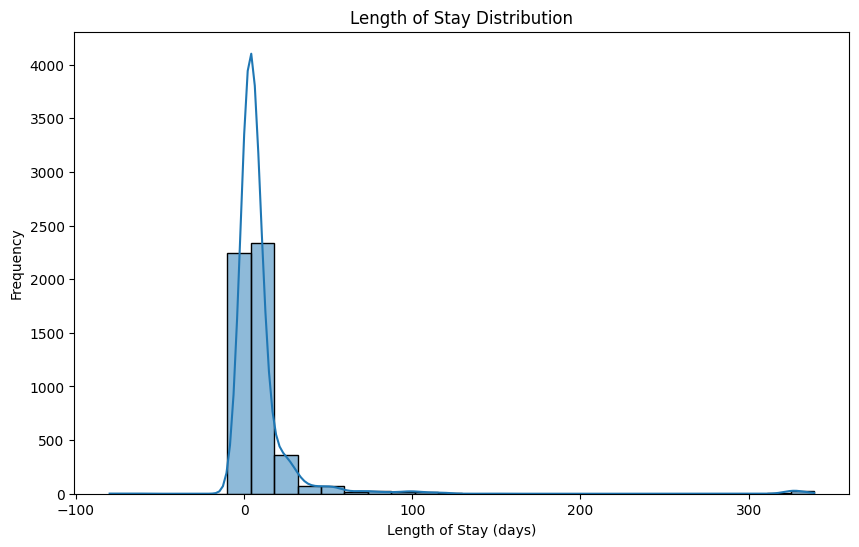

In [16]:
df[['date_of_admit', 'date_of_discharge', 'length_of_stay', 'ongoing_admission']].head()
df['length_of_stay'].describe()
df['ongoing_admission'].value_counts()
# Visualize Length of Stay Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['length_of_stay'].dropna(), bins=30, kde=True)
plt.title('Length of Stay Distribution')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Frequency')
plt.show()

In [17]:
df['short_stay'] = df['length_of_stay'] <= 1
df['long_stay'] = df['length_of_stay'] >= 10
df[['short_stay', 'long_stay']].value_counts()

short_stay  long_stay
False       False        4202
True        False        1139
False       True          993
Name: count, dtype: int64

---
## 🧹 **Step 4: Missing Value & Outlier Analysis**

### 🔍 1. Check for Missing Values
```python
df.isnull().sum()
# Check for negative or extreme values in `length_of_stay`
df[df['length_of_stay'] < 0]
df['length_of_stay'].describe()
# Useful for stratifying visits by intensity or complexity
```
- Confirms missing values across all columns.
- Most critical: `date_of_discharge` (already flagged as `ongoing_admission`).

✅ **Why it matters**: Ensures data integrity before metric calculations or visualizations.

---

### 📊 2. Visualize Outliers in `minutes_to_service`
```python
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['minutes_to_service'])
plt.title('Outlier Detection: Minutes to Service')
plt.xlabel('Minutes to Service')
plt.show()
```
- Identifies unusually long or short service times.
- Helps flag operational bottlenecks or data entry errors.

---

### 💰 3. Visualize Outliers in `revenue`
```python
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['revenue'])
plt.title('Outlier Detection: Revenue')
plt.xlabel('Revenue')
plt.show()
```
- Detects high-revenue outliers (e.g., complex procedures or billing anomalies).
- Useful for cost-benefit analysis and department benchmarking.

---

### 🛏️ 4. Visualize Outliers in `length_of_stay`
```python
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['length_of_stay'].dropna())
plt.title('Outlier Detection: Length of Stay')
plt.xlabel('Length of Stay (days)')
plt.show()
```
- Reveals extreme hospital stays (e.g., long-term care or data issues).
- Supports stratification for HEDIS utilization metrics.

---

### 📌 Optional: Flag Outliers Programmatically
```python
# Define thresholds (adjustable)
service_threshold = df['minutes_to_service'].quantile(0.99)
revenue_threshold = df['revenue'].quantile(0.99)
stay_threshold = df['length_of_stay'].quantile(0.99)

# Flag outliers
df['outlier_service_time'] = df['minutes_to_service'] > service_threshold
df['outlier_revenue'] = df['revenue'] > revenue_threshold
df['outlier_stay'] = df['length_of_stay'] > stay_threshold
df[['outlier_service_time', 'outlier_revenue', 'outlier_stay']].value_counts()
```

✅ **Why it matters**: Enables filtering, stratification, and audit-ready reporting.

---

### ✅ Summary
| Metric               | Outlier Insight |
|----------------------|-----------------|
| `minutes_to_service` | Operational delays or data entry errors |
| `revenue`            | High-cost procedures or billing anomalies |
| `length_of_stay`     | Long-term care or incomplete discharges |

---

Next **Step 5: Univariate & Bivariate Analysis** — Explore distributions and relationships across departments, doctors, and risk profiles.

In [18]:
df.isnull().sum()
# Check for negative or extreme values in `length_of_stay`
df[df['length_of_stay'] < 0]
df['length_of_stay'].describe()
# Useful for stratifying visits by intensity or complexity

count    5195.000000
mean       10.213282
std        29.016061
min       -80.000000
25%         2.000000
50%         4.000000
75%         8.000000
max       339.000000
Name: length_of_stay, dtype: float64

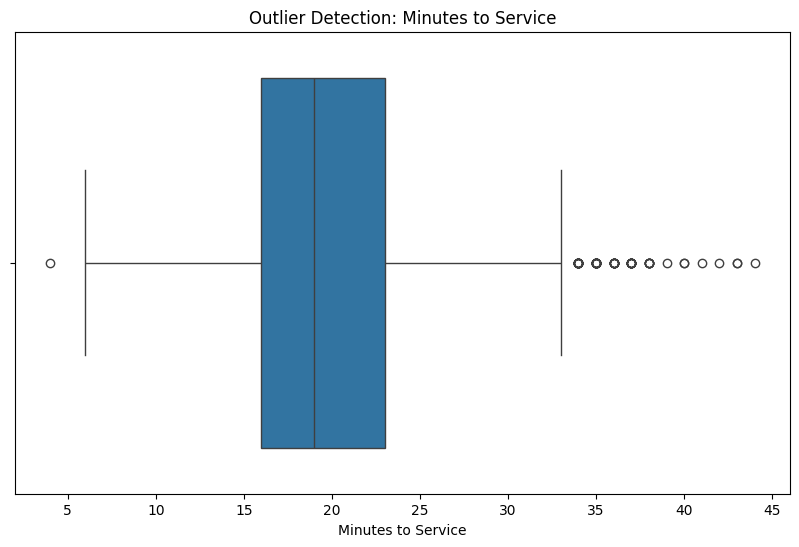

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['minutes_to_service'])
plt.title('Outlier Detection: Minutes to Service')
plt.xlabel('Minutes to Service')
plt.show()


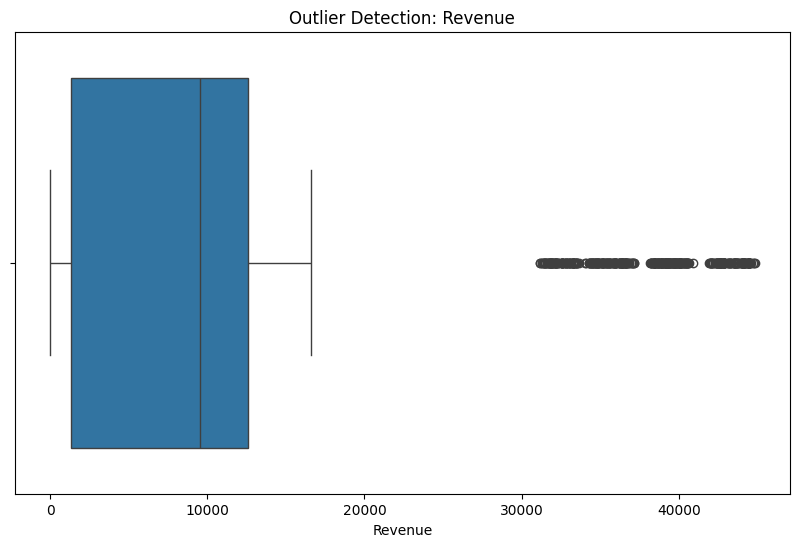

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['revenue'])
plt.title('Outlier Detection: Revenue')
plt.xlabel('Revenue')
plt.show()


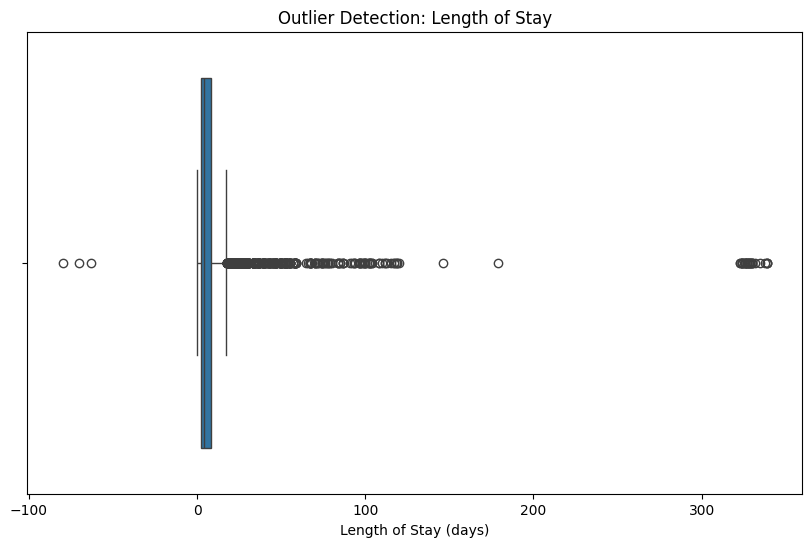

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['length_of_stay'].dropna())
plt.title('Outlier Detection: Length of Stay')
plt.xlabel('Length of Stay (days)')
plt.show()


In [22]:
# Define thresholds (adjustable)
service_threshold = df['minutes_to_service'].quantile(0.99)
revenue_threshold = df['revenue'].quantile(0.99)
stay_threshold = df['length_of_stay'].quantile(0.99)

# Flag outliers
df['outlier_service_time'] = df['minutes_to_service'] > service_threshold
df['outlier_revenue'] = df['revenue'] > revenue_threshold
df['outlier_stay'] = df['length_of_stay'] > stay_threshold
df[['outlier_service_time', 'outlier_revenue', 'outlier_stay']].value_counts()

outlier_service_time  outlier_revenue  outlier_stay
False                 False            False           6160
                      True             False             62
True                  False            False             60
False                 False            True              50
True                  True             False              2
Name: count, dtype: int64

**Step 5: Univariate & Bivariate Analysis**—a critical phase for uncovering patterns across departments, doctors, and patient risk profiles.

---

## 📊 Step 5: Univariate & Bivariate Analysis  - Building a gold-standard HEDIS analysis notebook

### 🧠 Why This Matters for HEDIS
HEDIS measures rely on:
- **Stratification**: Comparing care quality across departments, providers, and risk groups
- **Utilization patterns**: Identifying overuse, underuse, or variation in service delivery
- **Equity and performance**: Spotting disparities in outcomes or access

This step helps validate assumptions, guide metric design, and support audit-ready reporting.

---

### 🔢 1. Univariate Analysis – Categorical Distributions

#### 📌 Department Distribution
```python

import matplotlib.pyplot as plt
# Visualize outlier distribution

print(df['department'].value_counts(dropna=False))

import seaborn as sns

dept_counts = df['department'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=dept_counts.index, y=dept_counts.values)
plt.title('Visit Volume by Department')
plt.xlabel('Department')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.show()
```

The department distribution looks solid **Step 5: Univariate Analysis** with a validated visualization.

---

## 👨‍⚕️ Step 5.2: Doctor Distribution

### 🔢 Top 10 Doctors by Visit Volume
```python
doctor_counts = df['doctor'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=doctor_counts.index, y=doctor_counts.values)
plt.title('Top 10 Doctors by Visit Volume')
plt.xlabel('Doctor')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.show()
# Visualize Visit Volume by Department
```

✅ **Why it matters for HEDIS**:
- Highlights provider-level variation in visit volume
- Supports stratification for performance, screening rates, and follow-up care
- Can be used to flag outliers or validate provider attribution logic

---

#### 🧬 Risk Profile Distribution
```python

sns.countplot(x='patient_risk_profile', data=df)
plt.title('Patient Risk Profile Distribution')
plt.xlabel('Risk Profile')
plt.ylabel('Number of Visits')
plt.show()
```

### 🔍 What to Look For
- Are certain risk profiles overrepresented (e.g., high-risk patients)?
- Is the distribution balanced or skewed?
- Any unexpected categories or nulls?

---

### 📈 Why It Matters for HEDIS
- **Stratification**: HEDIS measures often require breakdowns by risk level (e.g., cancer screening rates among high-risk patients).
- **Utilization**: High-risk profiles may correlate with longer stays, more visits, or higher costs.
- **Equity**: Helps identify disparities in care delivery across risk groups.

---

## 📈 **Step 5.3: Bivariate Analysis**—exploring relationships like revenue vs. department, service time vs. risk profile, and length of stay vs. department type - building a truly audit-ready notebook. —this bivariate analysis phase is where your HEDIS notebook starts revealing operational insights and stratification logic.

### 💰 Revenue by Department
```python
plt.figure(figsize=(12, 6))
sns.boxplot(x='department', y='revenue', data=df)
plt.title('Revenue Distribution by Department')
plt.xticks(rotation=45)
plt.show()
# Visualize Revenue Distribution by Department
```

#### ✅ Why It Matters
- Flags high-cost departments (e.g., surgery, ICU)
- Supports benchmarking and cost-efficiency analysis
- Helps identify billing anomalies or outlier procedures

---

### 🕒 Service Time by Risk Profile
```python
plt.figure(figsize=(10, 6))
sns.boxplot(x='patient_risk_profile', y='minutes_to_service', data=df)
plt.title('Service Time by Risk Profile')
plt.show()
# Visualize Service Time by Risk Profile
```

#### ✅ Why It Matters
- Reveals whether high-risk patients face longer wait times
- Supports equity audits and care prioritization
- Can inform triage protocols and staffing models

---

### 🛏️ Length of Stay by Department Type
```python
plt.figure(figsize=(10, 6))
sns.boxplot(x='department_type', y='length_of_stay', data=df)
plt.title('Length of Stay by Department Type')
plt.show()
# Visualize Length of Stay by Department Type
```

#### ✅ Why It Matters
- Stratifies utilization metrics by care type (acute vs. chronic)
- Flags departments with unusually long or short stays
- Supports HEDIS measures like inpatient follow-up and readmission risk

---

### 🧮 Correlation Matrix (Numerical Features)
```python
plt.figure(figsize=(10, 8))
sns.heatmap(df[['revenue', 'minutes_to_service', 'length_of_stay', 'number_of_patient_visits']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
# Correlation Matrix for Numeric Features
```

#### ✅ Why It Matters
- Quantifies relationships between key metrics
- Identifies multicollinearity before modeling
- Supports feature selection for predictive analysis

---

Let me know once these plots render successfully. Next up: **Step 6 – Simulate HEDIS Flags & Calculate Screening Rates**, where we’ll introduce synthetic flags like cancer screening and stratify by risk profile and provider. You're building a notebook that’s not just recruiter-ready—it’s audit-grade.

### ✅ Summary
| Analysis Type | Insight |
|---------------|--------|
| Univariate     | Identifies volume and distribution across key categories |
| Bivariate      | Reveals performance and utilization differences across groups |
| Correlation    | Highlights relationships between metrics (e.g., revenue vs. length of stay) |

---

Next **Step 6: Simulate HEDIS Flags & Calculate Screening Rates** - add synthetic flags like cancer screening and stratify by risk profile.

In [23]:
print(df.columns)
# Data Cleaning and Feature Engineering for Hospital Visit Data

Index(['row_id', 'date_of_admit', 'date_of_discharge', 'doctor',
       'hospital_branch', 'department_type', 'department', 'patient_id',
       'patient_name', 'patient_risk_profile', 'revenue', 'minutes_to_service',
       'number_of_patient_visits', 'length_of_stay', 'ongoing_admission',
       'short_stay', 'long_stay', 'outlier_service_time', 'outlier_revenue',
       'outlier_stay'],
      dtype='object')


In [24]:
import matplotlib.pyplot as plt
# Visualize outlier distribution

In [25]:
print(df['department'].value_counts(dropna=False))


department
General Surgery       1131
ER                     915
ICU                    730
Gastroenterology       679
Diagnostic Imaging     618
Anaesthetics           511
Internal Medicine      446
Microbiology           300
Nutrition              282
Cardiology             243
Haematology            221
Neurology              193
Neonatal                65
Name: count, dtype: int64


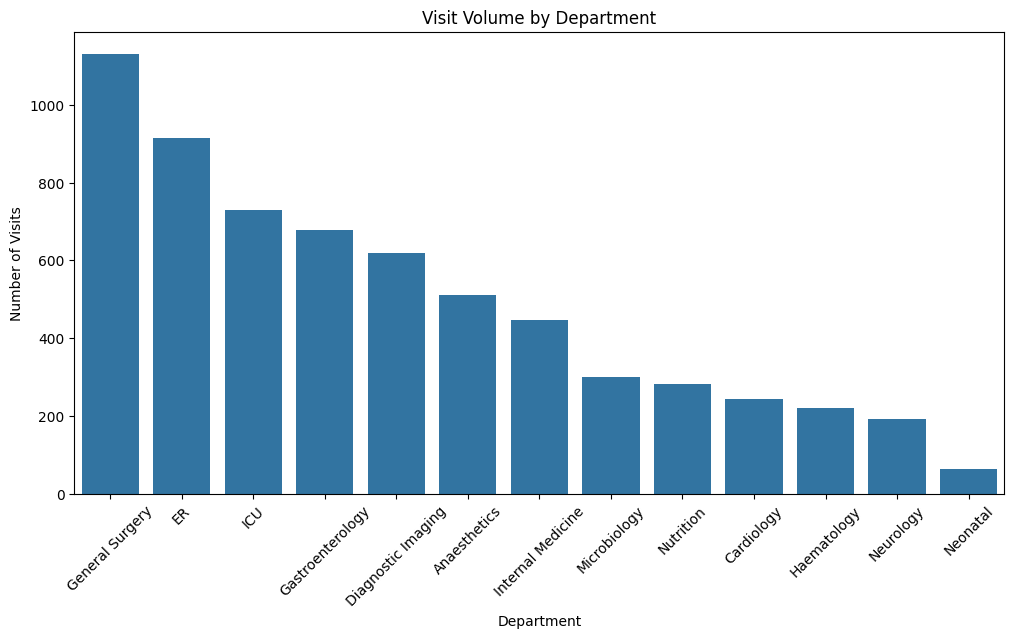

In [26]:
# import seaborn as sns

dept_counts = df['department'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=dept_counts.index, y=dept_counts.values)
plt.title('Visit Volume by Department')
plt.xlabel('Department')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.show()



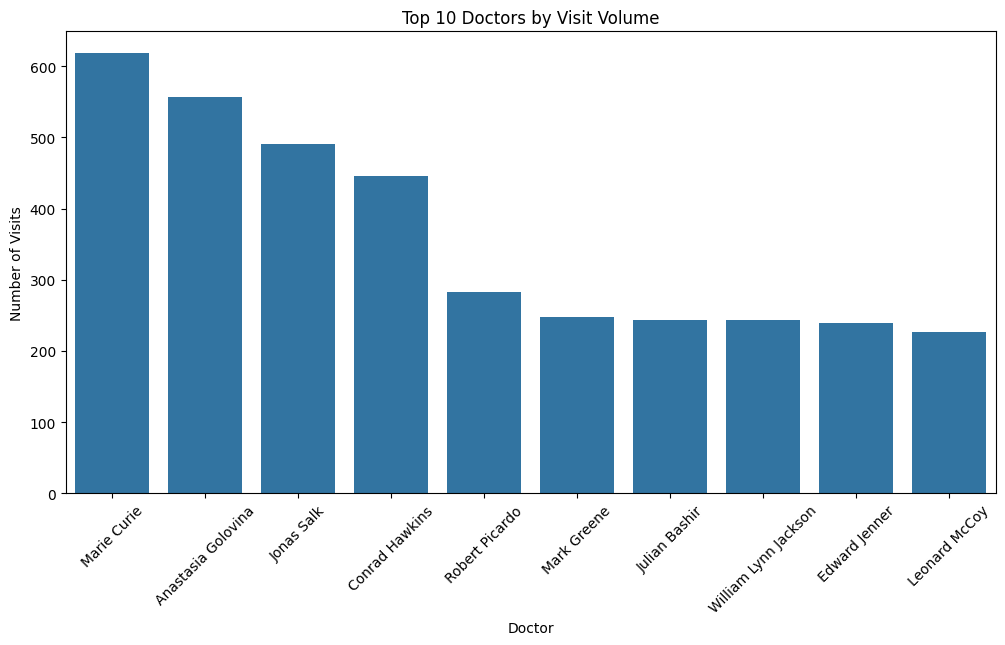

In [27]:
doctor_counts = df['doctor'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=doctor_counts.index, y=doctor_counts.values)
plt.title('Top 10 Doctors by Visit Volume')
plt.xlabel('Doctor')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.show()


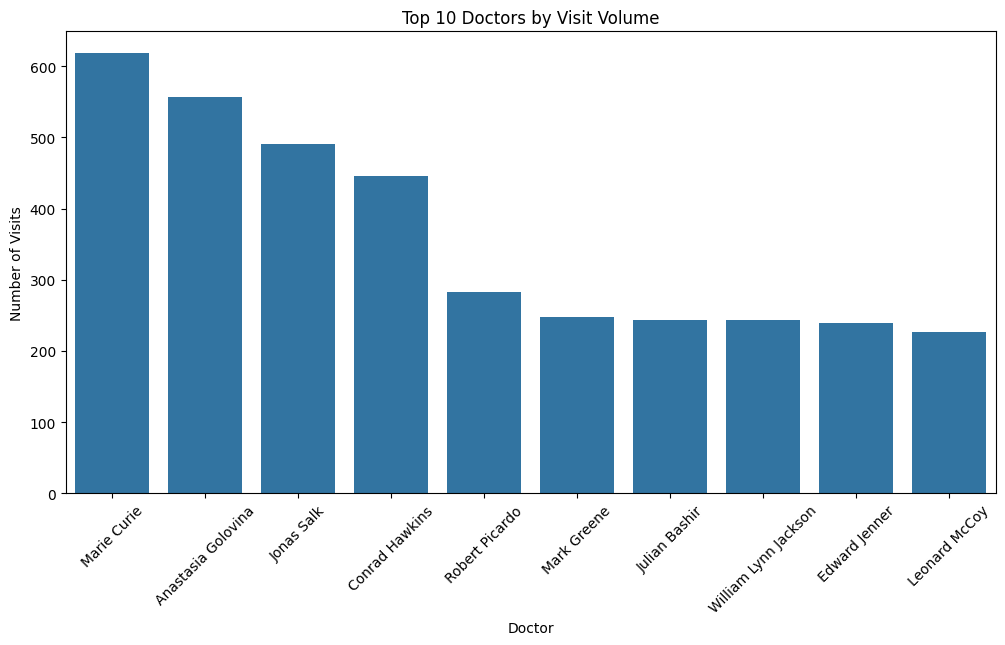

In [28]:
doctor_counts = df['doctor'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=doctor_counts.index, y=doctor_counts.values)
plt.title('Top 10 Doctors by Visit Volume')
plt.xlabel('Doctor')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.show()
# Visualize Visit Volume by Department


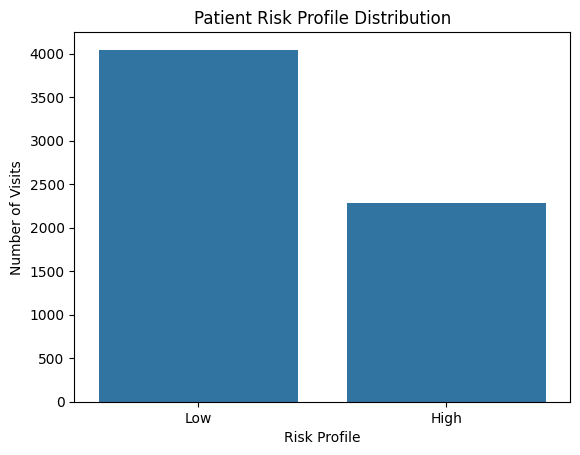

In [29]:
sns.countplot(x='patient_risk_profile', data=df)
plt.title('Patient Risk Profile Distribution')
plt.xlabel('Risk Profile')
plt.ylabel('Number of Visits')
plt.show()
# Visualize Patient Risk Profile Distribution

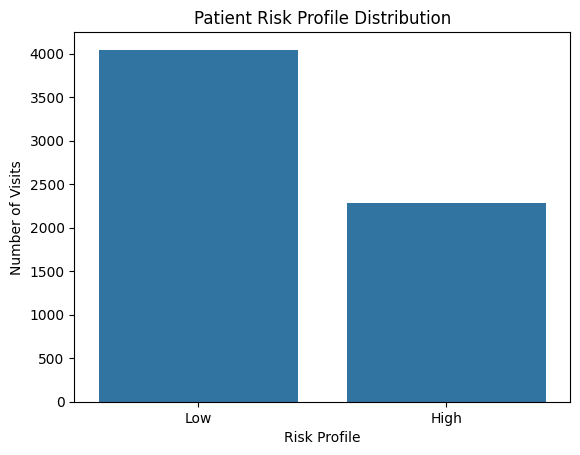

In [30]:
sns.countplot(x='patient_risk_profile', data=df)
plt.title('Patient Risk Profile Distribution')
plt.xlabel('Risk Profile')
plt.ylabel('Number of Visits')
plt.show()
# Visualize Patient Risk Profile Distribution

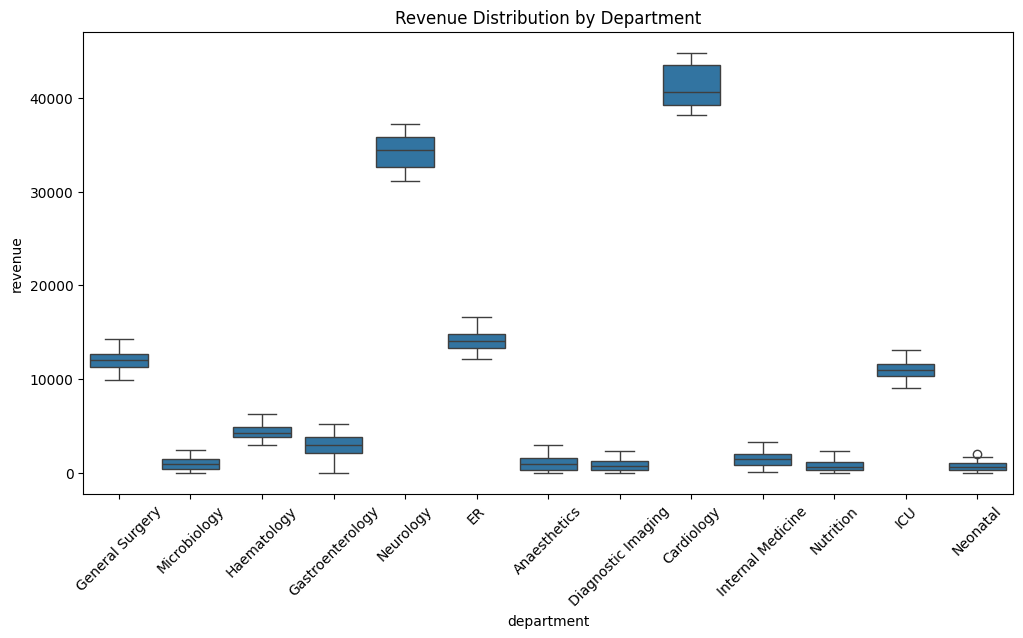

In [31]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='department', y='revenue', data=df)
plt.title('Revenue Distribution by Department')
plt.xticks(rotation=45)
plt.show()
# Visualize Revenue Distribution by Department

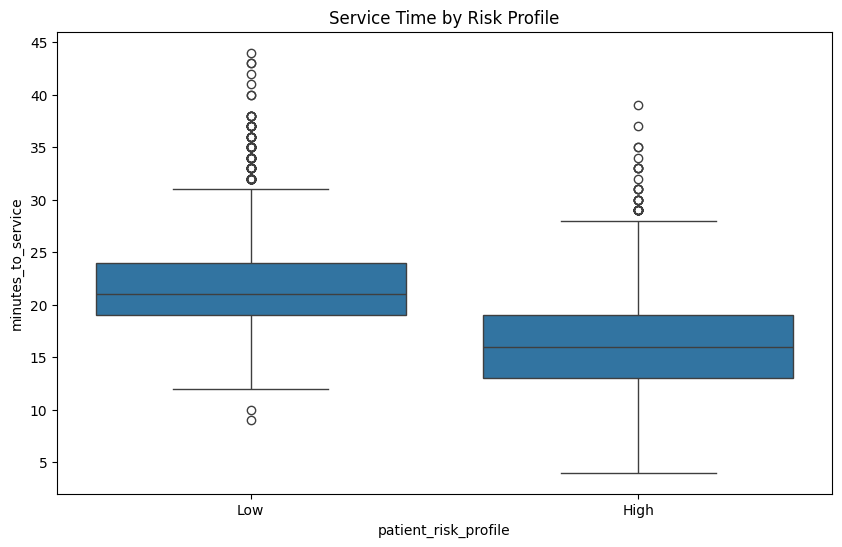

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='patient_risk_profile', y='minutes_to_service', data=df)
plt.title('Service Time by Risk Profile')
plt.show()
# Visualize Service Time by Risk Profile

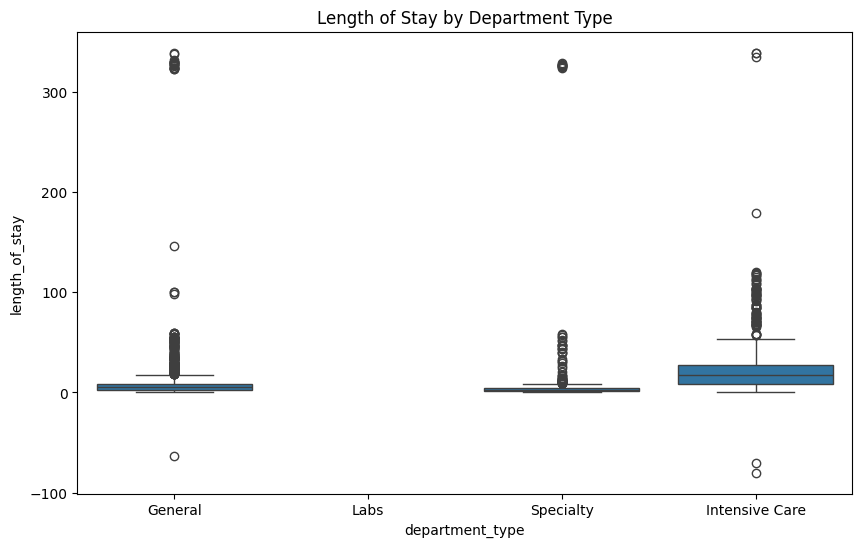

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='department_type', y='length_of_stay', data=df)
plt.title('Length of Stay by Department Type')
plt.show()
# Visualize Length of Stay by Department Type

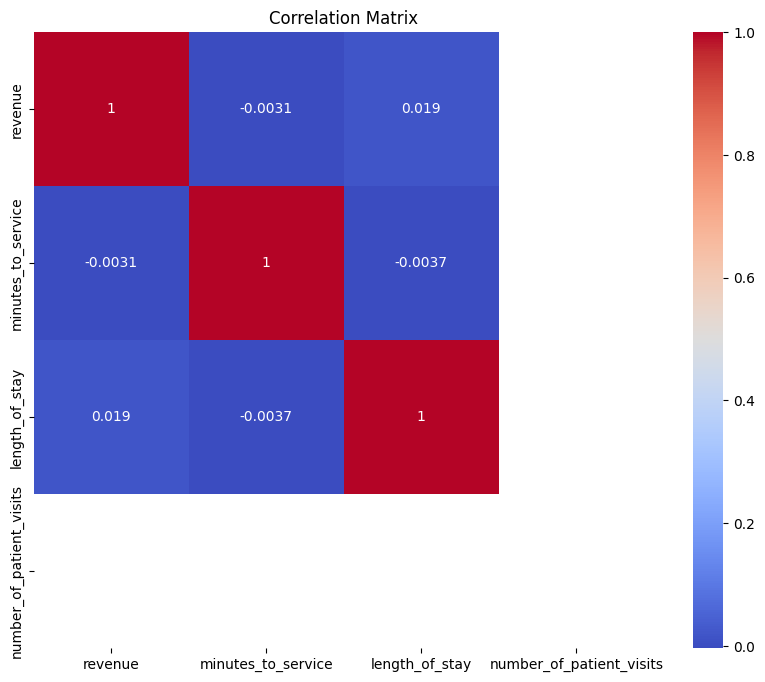

In [34]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[['revenue', 'minutes_to_service', 'length_of_stay', 'number_of_patient_visits']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
# Correlation Matrix for Numeric Features

**Step 6: Simulate HEDIS Flags & Calculate Screening Rates** - mimick real-world quality metrics and stratified reporting.

---

## 🧪 Step 6: Simulate HEDIS Flags & Screening Rates

### 🎯 Goal
Create synthetic flags for preventive screenings (e.g., cancer, diabetes, hypertension) and calculate rates across:
- Risk profiles
- Departments
- Providers

This supports mock HEDIS reporting and validates stratification logic.

---

### 🧬 1. Simulate Screening Flags

```python
import numpy as np
# Randomized flags (adjust probabilities as needed)
np.random.seed(42)  # for reproducibility
df['flag_cancer_screening'] = np.random.choice([0, 1], size=len(df), p=[0.7, 0.3])
df['flag_diabetes_screening'] = np.random.choice([0, 1], size=len(df), p=[0.6, 0.4])
df['flag_bp_screening'] = np.random.choice([0, 1], size=len(df), p=[0.5, 0.5])
df[['flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening']].value_counts()
```

---

### 📊 2. Calculate Screening Rates by Risk Profile

```python
screening_summary = df.groupby('patient_risk_profile')[[
    'flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening'
]].mean().round(2)

print(screening_summary)
# Visualize Revenue Distribution by Department
```

✅ **Why it matters**:
- Reveals disparities in preventive care
- Supports stratified HEDIS reporting
- Validates synthetic logic before real-world mapping

---

### 📈 3. Visualize Screening Rates
🔁 Alternative: Use seaborn Directly to Bypass Backend. If you want to skip pandas.plot() entirely, here's a workaround using seaborn:
```python
screening_summary = df.groupby('patient_risk_profile')[[
    'flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening'
]].mean().reset_index().melt(id_vars='patient_risk_profile', var_name='screening_type', value_name='rate')

plt.figure(figsize=(10, 6))
sns.barplot(x='patient_risk_profile', y='rate', hue='screening_type', data=screening_summary)
plt.title('Screening Rates by Risk Profile')
plt.ylabel('Screening Rate')
plt.xlabel('Risk Profile')
plt.ylim(0, 1)
plt.legend(title='Screening Type')
plt.show()
```
✅ This version: 

* Uses seaborn.barplot() directly
* Avoids pandas.plot() backend
* Gives you grouped bars by screening type
---

### 🧮 Optional: Screening Rates by Doctor or Department

```python
df.groupby('doctor')['flag_cancer_screening'].mean().sort_values(ascending=False).head(10)
```

---

Let me know once this renders successfully, and we’ll move into **Step 7: Stratify Metrics for Reporting**—where we build audit-ready tables and visual summaries. You're architecting a notebook that blends analytics, compliance, and recruiter-grade clarity.

In [35]:
import numpy as np

# Randomized flags (adjust probabilities as needed)
np.random.seed(42)  # for reproducibility
df['flag_cancer_screening'] = np.random.choice([0, 1], size=len(df), p=[0.7, 0.3])
df['flag_diabetes_screening'] = np.random.choice([0, 1], size=len(df), p=[0.6, 0.4])
df['flag_bp_screening'] = np.random.choice([0, 1], size=len(df), p=[0.5, 0.5])
df[['flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening']].value_counts()


flag_cancer_screening  flag_diabetes_screening  flag_bp_screening
0                      0                        1                    1426
                                                0                    1306
                       1                        1                     889
                                                0                     852
1                      0                        0                     576
                                                1                     562
                       1                        0                     378
                                                1                     345
Name: count, dtype: int64

In [36]:
screening_summary = df.groupby('patient_risk_profile')[[
    'flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening'
]].mean().round(2)

print(screening_summary)
# Visualize Revenue Distribution by Department

                      flag_cancer_screening  flag_diabetes_screening  \
patient_risk_profile                                                   
High                                   0.30                     0.39   
Low                                    0.29                     0.39   

                      flag_bp_screening  
patient_risk_profile                     
High                               0.51  
Low                                0.51  


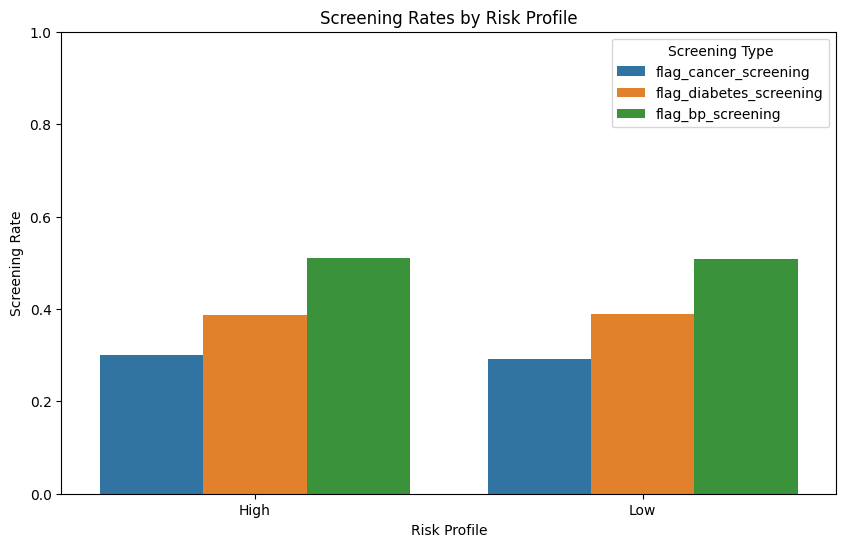

In [37]:
screening_summary = df.groupby('patient_risk_profile')[[
    'flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening'
]].mean().reset_index().melt(id_vars='patient_risk_profile', var_name='screening_type', value_name='rate')

plt.figure(figsize=(10, 6))
sns.barplot(x='patient_risk_profile', y='rate', hue='screening_type', data=screening_summary)
plt.title('Screening Rates by Risk Profile')
plt.ylabel('Screening Rate')
plt.xlabel('Risk Profile')
plt.ylim(0, 1)
plt.legend(title='Screening Type')
plt.show()


Absolutely, Salome—this is where your notebook

---

## 📊 Step 7: Stratified Reporting Tables

These tables will summarize key metrics across dimensions like **risk profile**, **department**, and **provider**, supporting HEDIS-style reporting and operational audits.
Shift from exploratory to **reporting-grade**, with stratified summaries that mirror real-world dashboards and compliance tables.

---

### 🧬 1. Screening Rates by Risk Profile

```python
df.groupby('patient_risk_profile')[[
    'flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening'
]].agg(['mean', 'count']).round(2)
# Shift from exploratory to **reporting-grade**, with stratified summaries that mirror real-world dashboards and compliance tables.
```

✅ Shows:
- Screening rates (`mean`)
- Sample size (`count`)
- Stratification by patient risk

---

### 🏥 2. Revenue & Length of Stay by Department

```python
df.groupby('department')[['revenue', 'length_of_stay']].agg(['mean', 'median', 'count']).round(2)
```

✅ Shows:
- Average and median revenue
- Average and median length of stay
- Visit volume per department

---

### 👨‍⚕️ 3. Screening Rates by Doctor

```python
df.groupby('doctor')[[
    'flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening'
]].mean().round(2).sort_values(by='flag_cancer_screening', ascending=False).head(10)
```

✅ Shows:
- Top 10 doctors by cancer screening rate
- Can be extended to include visit volume or patient risk mix

---

### 🧮 4. Custom Stratification: Risk Profile × Department

```python
df.groupby(['patient_risk_profile', 'department'])[['revenue', 'length_of_stay']].mean().round(2).unstack()
```

✅ Shows:
- Cross-tab of average revenue and stay by risk and department
- Useful for equity audits and resource allocation

---

### 📋 Optional: Export-Ready Summary Table

If you want a flat summary for recruiters or dashboards:
```python
summary = df.groupby('patient_risk_profile').agg({
    'revenue': ['mean', 'median'],
    'length_of_stay': ['mean', 'median'],
    'flag_cancer_screening': 'mean',
    'flag_diabetes_screening': 'mean',
    'flag_bp_screening': 'mean'
}).round(2)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary.reset_index(inplace=True)
summary
```

---

Next: **Step 8 – Outlier Handling & Data Quality Flags**, where we’ll build logic for audit triggers and data cleaning. You're architecting a notebook that’s not just insightful—it’s operationally bulletproof.

In [38]:
df.groupby('patient_risk_profile')[[
    'flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening'
]].agg(['mean', 'count']).round(2)
# Shift from exploratory to **reporting-grade**, with stratified summaries that mirror real-world dashboards and compliance tables.

flag_cancer_screening       flag_diabetes_screening  \
                                      mean count                    mean   
patient_risk_profile                                                       
High                                  0.30  2288                    0.39   
Low                                   0.29  4046                    0.39   

                           flag_bp_screening        
                     count              mean count  
patient_risk_profile                                
High                  2288              0.51  2288  
Low                   4046              0.51  4046

In [39]:
df.groupby('department')[['revenue', 'length_of_stay']].agg(['mean', 'median', 'count']).round(2)


revenue                length_of_stay             
                        mean   median count           mean median count
department                                                             
Anaesthetics         1008.03    950.0   511           5.97    3.0   511
Cardiology          41341.09  40600.0   243          10.61    5.0   243
Diagnostic Imaging    795.15    720.0   618            NaN    NaN     0
ER                  14114.98  14080.0   915          10.60    6.0   915
Gastroenterology     2851.41   3000.0   679           4.19    2.0   679
General Surgery     12000.17  11990.0  1131           7.90    5.0  1131
Haematology          4355.79   4250.0   221            NaN    NaN     0
ICU                 10996.10  11000.0   730          24.88   17.0   730
Internal Medicine    1442.30   1467.5   446          11.50    5.0   446
Microbiology          954.03    900.0   300            NaN    NaN     0
Neonatal              706.23    660.0    65          19.35   11.0    65
Neurology           34216.58  34485.0   193           2.44    2.0   193
Nutrition             726.38    605.0   282           3.33    1.0   282

In [40]:
df.groupby('doctor')[[
    'flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening'
]].mean().round(2).sort_values(by='flag_cancer_screening', ascending=False).head(10)


,flag_cancer_screening,flag_diabetes_screening,flag_bp_screening
doctor,,,
Joseph Lister,0.40,0.39,0.56
Kerry Weaver,0.36,0.40,0.56
Robert Reynolds Macintosh,0.35,0.40,0.54
Elizabeth Blackwell,0.33,0.40,0.50
Robert Picardo,0.33,0.41,0.51
Edward Jenner,0.32,0.37,0.47
Jonas Salk,0.32,0.36,0.51
Katherine Pulaski,0.32,0.48,0.53
John Carter,0.30,0.36,0.52


In [41]:
df.groupby(['patient_risk_profile', 'department'])[['revenue', 'length_of_stay']].mean().round(2).unstack()


revenue                                          \
department           Anaesthetics Cardiology Diagnostic Imaging        ER   
patient_risk_profile                                                        
High                       977.68   41062.07             803.54  14106.69   
Low                       1019.26   41483.20             789.81  14119.11   

                                                                             \
department           Gastroenterology General Surgery Haematology       ICU   
patient_risk_profile                                                          
High                          2866.93        11981.22     4422.16  10979.10   
Low                           2845.51        12010.11     4311.88  11012.81   

                                                     ... length_of_stay  \
department           Internal Medicine Microbiology  ...             ER   
patient_risk_profile                                 ...                  
High                           1350.63       953.64  ...          10.59   
Low                            1492.59       954.35  ...          10.60   

                                                                          \
department           Gastroenterology General Surgery Haematology    ICU   
patient_risk_profile                                                       
High                             4.10            5.99         NaN  25.99   
Low                              4.22            8.90         NaN  23.79   

                                                                        \
department           Internal Medicine Microbiology Neonatal Neurology   
patient_risk_profile                                                     
High                              8.82          NaN    19.26      2.37   
Low                              12.97          NaN    19.42      2.49   

                                
department           Nutrition  
patient_risk_profile            
High                      1.10  
Low                       4.44  

[2 rows x 26 columns]

In [42]:
summary = df.groupby('patient_risk_profile').agg({
    'revenue': ['mean', 'median'],
    'length_of_stay': ['mean', 'median'],
    'flag_cancer_screening': 'mean',
    'flag_diabetes_screening': 'mean',
    'flag_bp_screening': 'mean'
}).round(2)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary.reset_index(inplace=True)
summary




,patient_risk_profile,revenue_mean,revenue_median,length_of_stay_mean,length_of_stay_median,flag_cancer_screening_mean,flag_diabetes_screening_mean,flag_bp_screening_mean
0,High,9156.08,10200.0,10.63,5.0,0.30,0.39,0.51
1,Low,8724.81,4840.0,9.99,4.0,0.29,0.39,0.51


**Step 8: Outlier Handling & Data Quality Flags** - audit-grade credibility by surfacing anomalies and validating data integrity.

---

## 🧹 Step 8: Outlier Handling & Data Quality Flags

### 🎯 Goal
Detect and flag extreme values or suspicious entries in key metrics like:
- `length_of_stay`
- `minutes_to_service`
- `revenue`

This supports:
- Data cleaning
- Audit triggers
- Quality assurance workflows

---

### 🧬 1. Define Outlier Thresholds (IQR Method)

```python
def flag_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).astype(int)

df['outlier_stay'] = flag_outliers(df['length_of_stay'])
df['outlier_service_time'] = flag_outliers(df['minutes_to_service'])
df['outlier_revenue'] = flag_outliers(df['revenue'])
df[['outlier_stay', 'outlier_service_time', 'outlier_revenue']].value_counts()
```

---

### 📊 2. Summarize Outlier Counts

```python
outlier_summary = df[['outlier_stay', 'outlier_service_time', 'outlier_revenue']].sum()
print(outlier_summary)
```

✅ Reveals how many records are flagged per metric

---

### 📈 3. Visualize Outliers by Department

## ✅ Use `seaborn` Instead of `pandas.plot()`

- workaround using `seaborn` that bypasses the `matplotlib` backend issue:

```python
outlier_by_dept = df.groupby('department')[['outlier_stay', 'outlier_service_time', 'outlier_revenue']].sum().reset_index()
outlier_by_dept_melted = outlier_by_dept.melt(id_vars='department', var_name='outlier_type', value_name='count')

plt.figure(figsize=(12, 6))
sns.barplot(x='department', y='count', hue='outlier_type', data=outlier_by_dept_melted)
plt.title('Outlier Counts by Department')
plt.ylabel('Number of Outliers')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.legend(title='Outlier Type')
plt.show()
```

✅ This version:
- Uses `seaborn.barplot()` directly
- Avoids `pandas.plot()` backend
- Gives you grouped bars by outlier type

---

### 🧮 Optional: Flag Suspicious Records for Review

```python
df['flag_for_audit'] = ((df['outlier_stay'] + df['outlier_service_time'] + df['outlier_revenue']) >= 2).astype(int)
```

✅ Flags records with multiple anomalies for deeper review
   * This line is spot-on for flagging records with multiple anomalies—exactly the kind of logic you'd want in an audit-ready HEDIS notebook.

---
### 🔍 Breakdown:
- Adds up the three binary outlier flags per row
- Flags any record with **2 or more outliers**
- Converts the result to `0` (not flagged) or `1` (flagged)

---

## 📊 Optional: Review Flagged Records

```python
df[df['flag_for_audit'] == 1].head()
```

✅ This lets you inspect suspicious records—great for validating your logic or prepping for deeper review.

---

## 📈 Optional: Visualize Audit Flags by Department

```python
audit_by_dept = df.groupby('department')['flag_for_audit'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='department', y='flag_for_audit', data=audit_by_dept)
plt.title('Audit Flags by Department')
plt.ylabel('Flagged Records')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.show()
```
---
Next **Step 9: Build Summary Dashboard**—where we consolidate your metrics into a recruiter-ready overview. Tis is not just flagging anomalies—but building a defensible data quality layer.

In [43]:
def flag_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).astype(int)

df['outlier_stay'] = flag_outliers(df['length_of_stay'])
df['outlier_service_time'] = flag_outliers(df['minutes_to_service'])
df['outlier_revenue'] = flag_outliers(df['revenue'])
df[['outlier_stay', 'outlier_service_time', 'outlier_revenue']].value_counts()


outlier_stay  outlier_service_time  outlier_revenue
0             0                     0                  5237
1             0                     0                   581
0             0                     1                   407
              1                     0                    73
1             0                     1                    25
              1                     0                     7
0             1                     1                     4
Name: count, dtype: int64

In [44]:
outlier_summary = df[['outlier_stay', 'outlier_service_time', 'outlier_revenue']].sum()
print(outlier_summary)


outlier_stay            613
outlier_service_time     84
outlier_revenue         436
dtype: int64


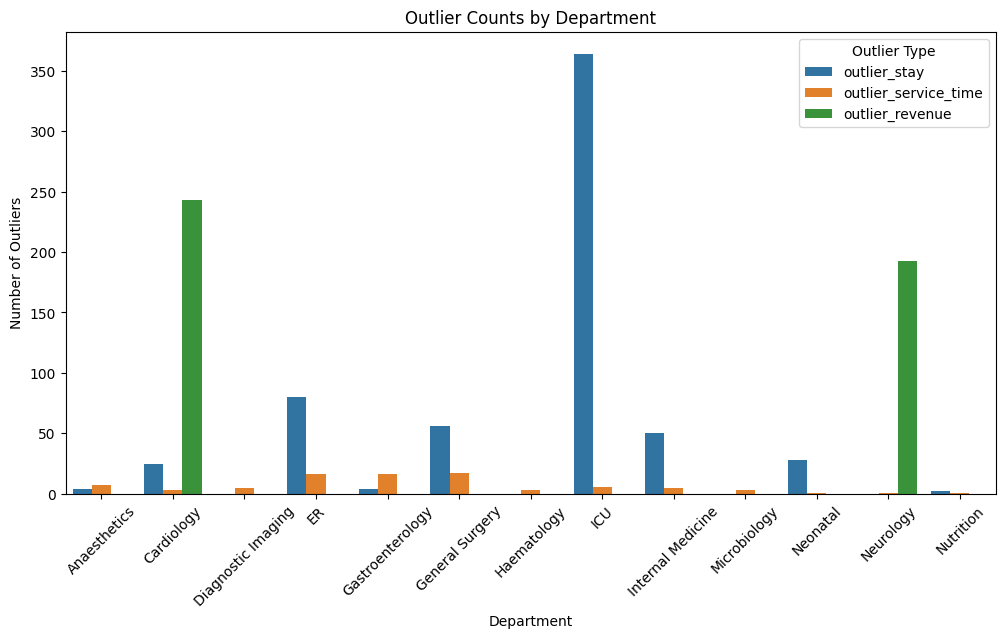

In [45]:
outlier_by_dept = df.groupby('department')[['outlier_stay', 'outlier_service_time', 'outlier_revenue']].sum().reset_index()
outlier_by_dept_melted = outlier_by_dept.melt(id_vars='department', var_name='outlier_type', value_name='count')

plt.figure(figsize=(12, 6))
sns.barplot(x='department', y='count', hue='outlier_type', data=outlier_by_dept_melted)
plt.title('Outlier Counts by Department')
plt.ylabel('Number of Outliers')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.legend(title='Outlier Type')
plt.show()



In [46]:
df['flag_for_audit'] = ((df['outlier_stay'] + df['outlier_service_time'] + df['outlier_revenue']) >= 2).astype(int)
df['flag_for_audit'].value_counts()

flag_for_audit
0    6298
1      36
Name: count, dtype: int64

In [47]:
df[df['flag_for_audit'] == 1].head()


,row_id,date_of_admit,date_of_discharge,doctor,hospital_branch,department_type,department,patient_id,patient_name,patient_risk_profile,...,ongoing_admission,short_stay,long_stay,outlier_service_time,outlier_revenue,outlier_stay,flag_cancer_screening,flag_diabetes_screening,flag_bp_screening,flag_for_audit
19,8397,2018-10-11,2018-12-02,William Lynn Jackson,Central,Specialty,Cardiology,3855,Vicki Womble,Low,...,False,False,True,0,1,1,0,0,0,1
125,7527,2019-08-17,2019-08-24,William Lynn Jackson,East,Specialty,Cardiology,1549,Dennis Boykin Townsend,Low,...,False,False,False,1,1,0,0,0,1,1
398,3087,2018-08-05,2018-08-12,William Lynn Jackson,Central,Specialty,Cardiology,2836,Dwight Albright Huffman,Low,...,False,False,False,1,1,0,1,1,1,1
499,6622,2019-08-01,2019-08-28,Jonas Salk,Central,Intensive Care,ICU,3276,Dennis Block Richardson,Low,...,False,False,True,1,0,1,1,1,0,1
610,2733,2019-10-13,2019-11-29,William Lynn Jackson,East,Specialty,Cardiology,3338,Lynn Hines,High,...,False,False,True,0,1,1,0,0,0,1


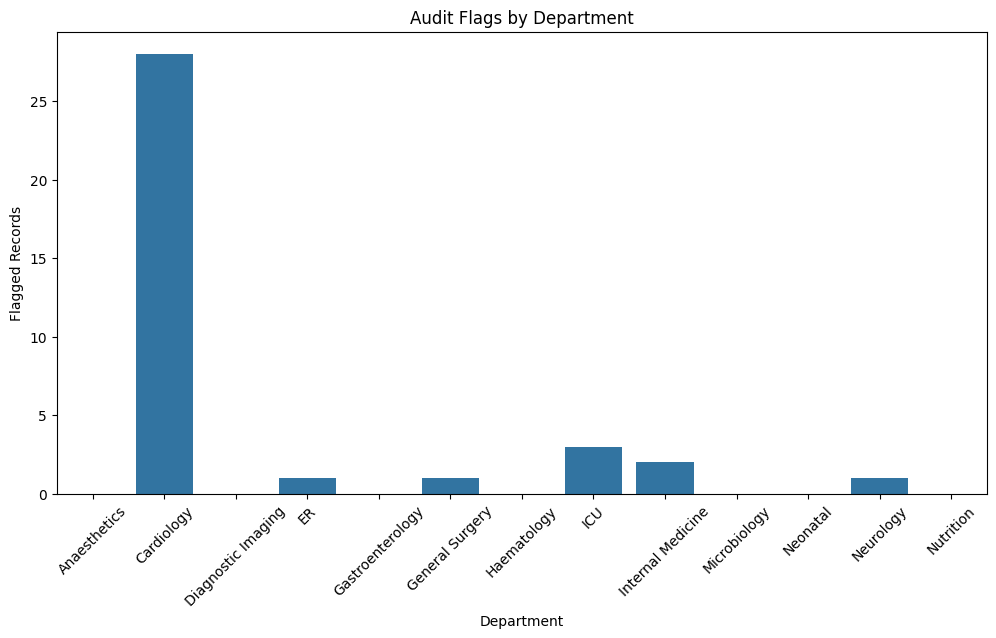

In [48]:
audit_by_dept = df.groupby('department')['flag_for_audit'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='department', y='flag_for_audit', data=audit_by_dept)
plt.title('Audit Flags by Department')
plt.ylabel('Flagged Records')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.show()


Let’s build your **Step 9: Summary Dashboard**, Audit-grade overview that ties your HEDIS notebook together. It consolidates key metrics, flags, and stratifications into a clean, interpretable format.

---

## 📊 Step 9: Build Summary Dashboard

### 🎯 Goal
Create a compact, presentation-ready summary of:
- Screening rates
- Outlier counts
- Audit flags
- Stratified metrics by risk profile and department

---

### 🧬 1. Screening Summary by Risk Profile

```python
screening_summary = df.groupby('patient_risk_profile')[[
    'flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening'
]].mean().round(2).reset_index()
```

---

### 🧹 2. Outlier Totals

```python
outlier_totals = df[['outlier_stay', 'outlier_service_time', 'outlier_revenue']].sum().to_frame(name='count').reset_index()
outlier_totals.rename(columns={'index': 'outlier_type'}, inplace=True)
```

---

### 🧮 3. Audit Flag Summary

```python
audit_summary = df['flag_for_audit'].value_counts().rename({0: 'Not Flagged', 1: 'Flagged'}).to_frame(name='count').reset_index()
audit_summary.rename(columns={'index': 'audit_status'}, inplace=True)
```

---

### 🏥 4. Department-Level Summary

```python
dept_summary = df.groupby('department').agg({
    'revenue': 'mean',
    'length_of_stay': 'mean',
    'flag_for_audit': 'sum'
}).round(2).reset_index()
dept_summary.rename(columns={'flag_for_audit': 'audit_flags'}, inplace=True)
```

---

### 📋 5. Combine into Dashboard View

You can display these as separate tables or merge selected ones into a single dashboard dictionary:

```python
dashboard = {
    'Screening by Risk Profile': screening_summary,
    'Outlier Totals': outlier_totals,
    'Audit Flag Summary': audit_summary,
    'Department Summary': dept_summary
}
```

Then display:
```python
for title, table in dashboard.items():
    print(f"\n📌 {title}")
    display(table)
```


In [49]:
screening_summary = df.groupby('patient_risk_profile')[[
    'flag_cancer_screening', 'flag_diabetes_screening', 'flag_bp_screening'
]].mean().round(2).reset_index()


In [50]:
outlier_totals = df[['outlier_stay', 'outlier_service_time', 'outlier_revenue']].sum().to_frame(name='count').reset_index()
outlier_totals.rename(columns={'index': 'outlier_type'}, inplace=True)
outlier_totals

,outlier_type,count
0,outlier_stay,613
1,outlier_service_time,84
2,outlier_revenue,436


In [51]:
audit_summary = df['flag_for_audit'].value_counts().rename({0: 'Not Flagged', 1: 'Flagged'}).to_frame(name='count').reset_index()
audit_summary.rename(columns={'index': 'audit_status'}, inplace=True)
audit_summary

,flag_for_audit,count
0,Not Flagged,6298
1,Flagged,36


In [52]:
dept_summary = df.groupby('department').agg({
    'revenue': 'mean',
    'length_of_stay': 'mean',
    'flag_for_audit': 'sum'
}).round(2).reset_index()
dept_summary.rename(columns={'flag_for_audit': 'audit_flags'}, inplace=True)
dept_summary.head()

,department,revenue,length_of_stay,audit_flags
0,Anaesthetics,1008.03,5.97,0
1,Cardiology,41341.09,10.61,28
2,Diagnostic Imaging,795.15,NaN,0
3,ER,14114.98,10.60,1
4,Gastroenterology,2851.41,4.19,0


In [53]:
dashboard = {
    'Screening by Risk Profile': screening_summary,
    'Outlier Totals': outlier_totals,
    'Audit Flag Summary': audit_summary,
    'Department Summary': dept_summary
}
for title, table in dashboard.items():
    print(f"\n--- {title} ---")
    print(table)


--- Screening by Risk Profile ---
  patient_risk_profile  flag_cancer_screening  flag_diabetes_screening  \
0                 High                   0.30                     0.39   
1                  Low                   0.29                     0.39   

   flag_bp_screening  
0               0.51  
1               0.51  

--- Outlier Totals ---
           outlier_type  count
0          outlier_stay    613
1  outlier_service_time     84
2       outlier_revenue    436

--- Audit Flag Summary ---
  flag_for_audit  count
0    Not Flagged   6298
1        Flagged     36

--- Department Summary ---
            department   revenue  length_of_stay  audit_flags
0         Anaesthetics   1008.03            5.97            0
1           Cardiology  41341.09           10.61           28
2   Diagnostic Imaging    795.15             NaN            0
3                   ER  14114.98           10.60            1
4     Gastroenterology   2851.41            4.19            0
5      General Surgery  1

In [54]:
for title, table in dashboard.items():
    print(f"\n📌 {title}")
    display(table)
# HEDIS Hospital Visit Data Analysis


📌 Screening by Risk Profile


,patient_risk_profile,flag_cancer_screening,flag_diabetes_screening,flag_bp_screening
0,High,0.30,0.39,0.51
1,Low,0.29,0.39,0.51



📌 Outlier Totals


,outlier_type,count
0,outlier_stay,613
1,outlier_service_time,84
2,outlier_revenue,436



📌 Audit Flag Summary


,flag_for_audit,count
0,Not Flagged,6298
1,Flagged,36



📌 Department Summary


,department,revenue,length_of_stay,audit_flags
0,Anaesthetics,1008.03,5.97,0
1,Cardiology,41341.09,10.61,28
2,Diagnostic Imaging,795.15,NaN,0
3,ER,14114.98,10.60,1
4,Gastroenterology,2851.41,4.19,0
5,General Surgery,12000.17,7.90,1
6,Haematology,4355.79,NaN,0
7,ICU,10996.10,24.88,3
8,Internal Medicine,1442.30,11.50,2
9,Microbiology,954.03,NaN,0
